# Model
### Mic Channel only
### OSA and Snore Class and No-Snore

In [1]:
import os, random, json, math
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    get_linear_schedule_with_warmup
)

c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [ ]:
TRAIN_NPY_DIR = Path(r"C:\V89\data2\train_npy")
TEST_NPY_DIR  = Path(r"C:\V89\data_test\test_npy")

TRAIN_CSV = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_train\train\use_train_ose_normal.csv"
TEST_CSV  = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test_ose_normal.csv"

SAVE_DIR  = Path(r"C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V4")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
TARGET_SR = 16000
SEGMENT_SECONDS = 5.0
SEG_SAMPLES = int(TARGET_SR * SEGMENT_SECONDS)
BATCH_SIZE = 4
EPOCHS = 20
LR = 1e-5
PROCESSOR_NAME = "facebook/wav2vec2-base-960h"  # Added missing processor name

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name())

Device: cuda
GPU: NVIDIA GeForce RTX 4060


In [4]:
# Three class mapping - changed from binary to three classes
def map_type_to_label(t: str) -> int:
    """
    Map type to three classes:
    0 = ObstructiveApnea
    1 = Snore
    2 = no_Snore
    """
    if t == "ObstructiveApnea":
        return 0
    elif t == "Snore":
        return 1
    elif t == "no_Snore":
        return 2
    else:
        # Handle other cases - you might want to adjust this based on your data
        print(f"Warning: Unknown type '{t}', mapping to no_Snore (2)")
        return 2

In [7]:
# Load processor
processor = Wav2Vec2Processor.from_pretrained(PROCESSOR_NAME)

# Data loading and preprocessing
df_train_all = pd.read_csv(TRAIN_CSV)
df_test_all  = pd.read_csv(TEST_CSV)

df_train_all["label"] = df_train_all["type"].map(map_type_to_label).astype(int)
df_test_all["label"]  = df_test_all["type"].map(map_type_to_label).astype(int)

# Check class distribution
print("Training data class distribution:")
print(df_train_all["label"].value_counts().sort_index())
print("\nTest data class distribution:")
print(df_test_all["label"].value_counts().sort_index())

train_df, val_df = train_test_split(
    df_train_all, test_size=0.2, stratify=df_train_all["label"], random_state=SEED
)
print(f"\nTrain size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(df_test_all)}")

c:\V89\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Abcde\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Training data class distribution:
label
0    645
1    279
2    240
Name: count, dtype: int64

Test data class distribution:
label
0    447
1    415
2    120
Name: count, dtype: int64

Train size: 931, Val size: 233, Test size: 982


In [14]:
def resolve_npy_path(root_dir: Path, pid: int, seg_index: int) -> Path | None:
    """
    patient_id + segment_index -> find Mic .npy file
    """
    pid_str = f"{int(pid):08d}"
    seg_str = f"[{int(seg_index)+1:03d}]"

    # common patterns
    candidates = [
        f"{pid_str}-100507{seg_str}_mic.npy",
        f"{pid_str}{seg_str}_mic.npy",
    ]

    for fname in candidates:
        path = root_dir / fname
        if path.exists():
            return path

    # fallback: search for files with pid + seg + _mic.npy
    hits = list(root_dir.rglob(f"*{pid_str}*{seg_str}*_mic.npy"))
    return hits[0] if hits else None

def load_mic_from_npy(npy_path: Path) -> np.ndarray | None:
    try:
        arr = np.load(npy_path).astype(np.float32)
        if arr.ndim > 1:
            arr = arr.reshape(-1)
        return arr
    except Exception as e:
        print(f"[load_mic_from_npy] error {npy_path}: {e}")
        return None

def slice_segment(wave: np.ndarray, start_sec: float, dur_sec: float,
                  sr: int = TARGET_SR, fixed_len: int = SEG_SAMPLES) -> np.ndarray | None:
    if wave is None or len(wave) == 0:
        return None
    start = int(max(0.0, float(start_sec)) * sr)
    end = start + int(float(dur_sec) * sr)
    if start >= len(wave):
        return None
    seg = wave[start:min(end, len(wave))]
    if len(seg) <= 0:
        return None
    if len(seg) < fixed_len:
        seg = np.pad(seg, (0, fixed_len - len(seg)), mode="constant")
    else:
        seg = seg[:fixed_len]
    return seg.astype(np.float32)

def collate_w2v2(batch):
    """Collate function for Wav2Vec2"""
    input_values = []
    labels = []
    
    for item in batch:
        if len(item) == 2:
            audio, label = item
            input_values.append(audio)
            labels.append(label)
    
    if not input_values:
        return {
            "input_values": torch.zeros((1, SEG_SAMPLES)),
            "attention_mask": None,
            "labels": torch.tensor([0])
        }
    
    # Process audio with Wav2Vec2Processor
    processed = processor(
        [x.numpy() for x in input_values],  # ensure it's a list of 1D numpy arrays
        sampling_rate=TARGET_SR, 
        return_tensors="pt", 
        padding=True
    )
    
    return {
        "input_values": processed.input_values,
        "attention_mask": processed.get("attention_mask", None),
        "labels": torch.stack(labels)
    }

In [15]:
class W2V2NpyDataset(Dataset):
    def __init__(self, df: pd.DataFrame, npy_root: Path, target_sr=TARGET_SR, seg_seconds=SEGMENT_SECONDS):
        self.df = df.reset_index(drop=True)
        self.root = npy_root
        self.target_sr = target_sr
        self.seg_seconds = seg_seconds

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            r = self.df.iloc[idx]
            pid = int(r["patient_id"])
            seg_index = int(r["segment_index"])
            start_sec = float(r.get("segment_local_start_sec", r.get("start_sec", 0.0)))
            dur_sec   = min(float(r.get("duration_sec", self.seg_seconds)), self.seg_seconds)

            p = resolve_npy_path(self.root, pid, seg_index)
            if p is None or not p.exists():
                raise FileNotFoundError(f"No file for pid={pid} seg={seg_index}")

            wave = load_mic_from_npy(p)
            seg  = slice_segment(wave, start_sec, dur_sec, sr=self.target_sr, fixed_len=SEG_SAMPLES)
            if seg is None:
                seg = slice_segment(wave, 0.0, self.seg_seconds, sr=self.target_sr, fixed_len=SEG_SAMPLES)
                if seg is None:
                    raise RuntimeError(f"Empty segment for {p}")

            y = int(r["label"])
            return torch.tensor(seg), torch.tensor(y, dtype=torch.long)

        except Exception as e:
            print(f"[Dataset] Skipping index {idx} due to error: {e}")
            return torch.zeros(SEG_SAMPLES, dtype=torch.float32), torch.tensor(0)

In [16]:
# Create datasets and dataloaders
train_ds = W2V2NpyDataset(train_df, TRAIN_NPY_DIR)
val_ds   = W2V2NpyDataset(val_df,   TRAIN_NPY_DIR)
test_ds  = W2V2NpyDataset(df_test_all, TEST_NPY_DIR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)

# Initialize model for 3 classes instead of 2
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    PROCESSOR_NAME,
    num_labels=3,  # Changed from 2 to 3
    problem_type="single_label_classification",
).to(device)

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.masked_spec_embed', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
# Freeze feature extractor
for p in model.wav2vec2.feature_extractor.parameters():
    p.requires_grad = False

# Compute class weights for 3 classes
cls_weights = compute_class_weight(
    class_weight="balanced", 
    classes=np.array([0, 1, 2]),  # Three classes
    y=train_df["label"].values
)
cls_weights_t = torch.tensor(cls_weights, dtype=torch.float32, device=device)
print("Class weights:", cls_weights_t.cpu().numpy())

# Loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=cls_weights_t)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
total_steps = EPOCHS * math.ceil(len(train_loader))
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)


Class weights: [0.6014212 1.3916293 1.6163194]


In [18]:
def run_eval(dataloader):
    """Evaluation function for 3-class classification"""
    model.eval()
    all_true, all_pred = [], []
    running_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device) if batch["attention_mask"] is not None else None
            labels = batch["labels"].to(device)

            outputs = model(input_values, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            # For multi-class, use argmax instead of threshold
            preds = torch.argmax(logits, dim=1)

            running_loss += loss.item()
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
    
    avg_loss = running_loss / max(1, len(dataloader))
    acc = (np.array(all_true) == np.array(all_pred)).mean()
    f1  = f1_score(all_true, all_pred, average="macro")
    return avg_loss, acc, f1, np.array(all_true), np.array(all_pred)

In [19]:
# Training loop
best_val_f1, best_epoch = 0.0, 0
train_losses, val_losses = [], []
train_f1s, val_f1s = [], []

for epoch in range(1, EPOCHS+1):
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    tr_true, tr_pred = [], []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device) if batch["attention_mask"] is not None else None
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_values, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits
        loss.backward()
        optimizer.step()
        scheduler.step()

        tr_loss += loss.item()
        # For multi-class, use argmax instead of threshold
        preds = torch.argmax(logits, dim=1)
        tr_correct += (preds == labels).sum().item()
        tr_total += labels.size(0)
        tr_true.extend(labels.cpu().numpy())
        tr_pred.extend(preds.cpu().numpy())

    train_acc = tr_correct / max(1, tr_total)
    train_f1  = f1_score(tr_true, tr_pred, average="macro")
    train_loss_avg = tr_loss / len(train_loader)

    val_loss, val_acc, val_f1, _, _ = run_eval(val_loader)
    
    # Store metrics for plotting
    train_losses.append(train_loss_avg)
    val_losses.append(val_loss)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)
    
    print(f"Epoch {epoch:02d} | "
          f"Train Loss {train_loss_avg:.4f} Acc {train_acc:.4f} F1 {train_f1:.4f}  ||  "
          f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} F1 {val_f1:.4f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_model_dir = SAVE_DIR / "wav2vec2_best"
        best_model_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(str(best_model_dir))
        processor.save_pretrained(str(best_model_dir))
        print(f"✅ New best model saved! F1: {best_val_f1:.4f} at epoch {best_epoch}")

print(f"\n🏆 Best validation F1: {best_val_f1:.4f} at epoch {best_epoch}")

Epoch 1/20 [Train]:   0%|          | 0/233 [00:00<?, ?it/s]

Epoch 01 | Train Loss 0.9501 Acc 0.5607 F1 0.2824  ||  Val Loss 0.8133 Acc 0.7167 F1 0.5265
✅ New best model saved! F1: 0.5265 at epoch 1


Epoch 2/20 [Train]:   0%|          | 0/233 [00:00<?, ?it/s]

Epoch 02 | Train Loss 0.7680 Acc 0.7143 F1 0.5262  ||  Val Loss 0.6822 Acc 0.7253 F1 0.5347
✅ New best model saved! F1: 0.5347 at epoch 2


Epoch 3/20 [Train]:   0%|          | 0/233 [00:00<?, ?it/s]

...

Epoch 18 | Train Loss 0.4173 Acc 0.8174 F1 0.7165  ||  Val Loss 0.5525 Acc 0.8112 F1 0.6953
✅ New best model saved! F1: 0.6953 at epoch 18


Epoch 19/20 [Train]:   0%|          | 0/233 [00:00<?, ?it/s]

Epoch 19 | Train Loss 0.4038 Acc 0.8238 F1 0.7383  ||  Val Loss 0.5276 Acc 0.8069 F1 0.7133
✅ New best model saved! F1: 0.7133 at epoch 19


Epoch 20/20 [Train]:   0%|          | 0/233 [00:00<?, ?it/s]

Epoch 20 | Train Loss 0.4050 Acc 0.8228 F1 0.7377  ||  Val Loss 0.4880 Acc 0.8498 F1 0.8032
✅ New best model saved! F1: 0.8032 at epoch 20

🏆 Best validation F1: 0.8032 at epoch 20



FINAL TEST EVALUATION
Test Loss: 0.9238
Test Accuracy: 0.7444
Test F1 (macro): 0.5771

Detailed Classification Report:
                  precision    recall  f1-score   support

ObstructiveApnea       0.73      0.70      0.72       447
           Snore       0.76      0.98      0.85       415
        no_Snore       0.61      0.09      0.16       120

        accuracy                           0.74       982
       macro avg       0.70      0.59      0.58       982
    weighted avg       0.73      0.74      0.71       982



<Figure size 800x600 with 0 Axes>

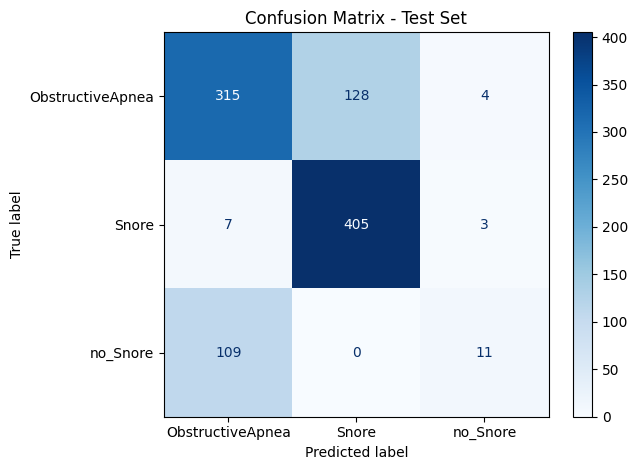

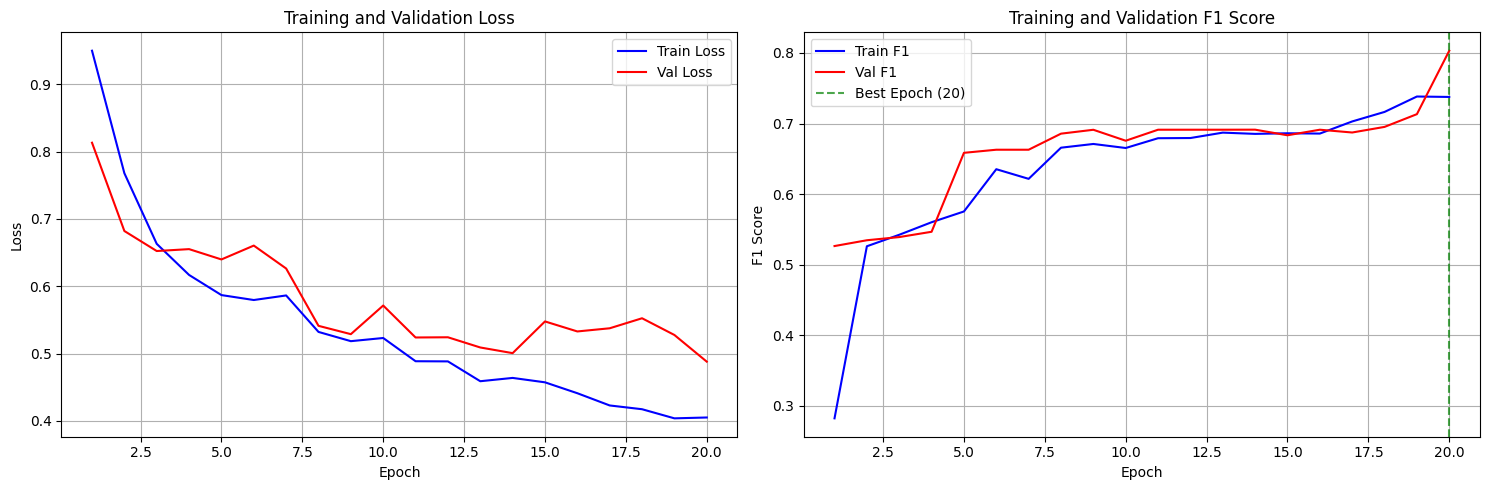

In [20]:
# Evaluate on test set
print("\n" + "="*50)
print("FINAL TEST EVALUATION")
print("="*50)

test_loss, test_acc, test_f1, y_true, y_pred = run_eval(test_loader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 (macro): {test_f1:.4f}")

# Classification report
class_names = ['ObstructiveApnea', 'Snore', 'no_Snore']
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax1.plot(range(1, EPOCHS+1), train_losses, 'b-', label='Train Loss')
ax1.plot(range(1, EPOCHS+1), val_losses, 'r-', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# F1 curves
ax2.plot(range(1, EPOCHS+1), train_f1s, 'b-', label='Train F1')
ax2.plot(range(1, EPOCHS+1), val_f1s, 'r-', label='Val F1')
ax2.axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.set_title('Training and Validation F1 Score')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [21]:
# Save final model
final_model_dir = SAVE_DIR / "wav2vec2_final"
final_model_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(str(final_model_dir))
processor.save_pretrained(str(final_model_dir))
print(f"\n💾 Final model saved to: {final_model_dir}")

# Save training history
history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_f1s': train_f1s,
    'val_f1s': val_f1s,
    'best_val_f1': best_val_f1,
    'best_epoch': best_epoch,
    'test_f1': test_f1,
    'test_acc': test_acc
}

with open(SAVE_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f"📊 Training history saved to: {SAVE_DIR / 'training_history.json'}")


💾 Final model saved to: C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V3\wav2vec2_final
📊 Training history saved to: C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V3\training_history.json
